# Grid Search hyper parameters for MAE-PU learning

1. Import dependencies

In [1]:
import random
import torch
import numpy as np
import pandas as pd
import time
import glob
import os
import torch.utils.data as data

from src.util.torch import resolve_torch_device
from src.data.indian_pines import load_indian_pines
from src.definitions import GREED_SEARCH_FOLDER, RAW_DATA_FOLDER
from src.model.grid_search import GridSearch
from src.model.bin_mae_pu_grid_search import BinMaePuSearchAdapter
from src.util.hsi import pu_bin_train_test_split_by_mask, read_fixed_labels_mask
from src.visualization.plot import plot_masked_segmentation_comparison
from src.util.hsi import (
    extract_patches,
    preprocess_hsi,
    reduce_hsi_dim,
    DimReductionType,
    PreProcessType,
)
from src.util.dict_ext import unique_counts
from src.data.dataset_decorator import UnlabeledDatasetDecorator
from src.util.loss import (
    double_hinge_loss,
    hinge_loss,
    logistic_loss,
    ramp_loss,
    sigmoid_loss,
    squared_loss,
    zero_one_loss,
)

2. Prepare env

In [2]:
random_seed = 42

random.seed(random_seed)
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = resolve_torch_device()

generator = torch.Generator()
generator.manual_seed(random_seed)

In [3]:
f"Device is {device}"

'Device is cuda'

# Indian pines

0. Set params

In [4]:
examples_per_class = 15
# epoch_seconds = int(time.time())
epoch_seconds = 1745249041
run_name = f"indian-pines-mae-pu-{epoch_seconds}"

In [5]:
cpu_count = 1

f"Setting num_workers to {cpu_count}"

'Setting num_workers to 1'

1. Load dataset

In [6]:
target_class = 11
data_point_count = 245

In [7]:
batch_size = 24
patch_size = 9
target_dim = 75

pre_process_type = PreProcessType.STANDARTIZATION
dim_reduction_type = DimReductionType.PCA

In [8]:
image, labels = load_indian_pines()

In [9]:
image_h, image_w, _ = image.shape

In [10]:
_, image = preprocess_hsi(image, pre_process_type)

In [11]:
_, target_dim, image = reduce_hsi_dim(
    image, target_dim, dim_reduction_type, device, random_seed
)

In [12]:
x, y = extract_patches(image, labels, patch_size=patch_size)

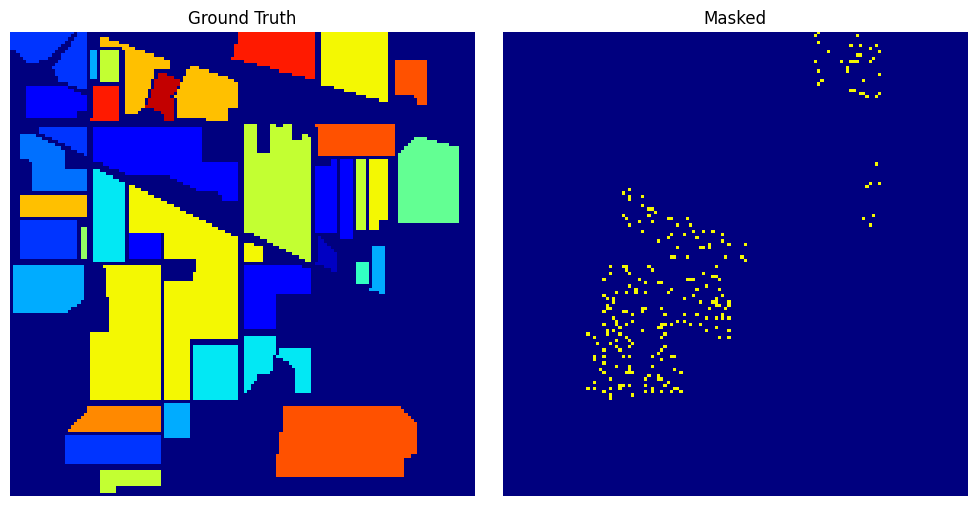

In [13]:
mask = read_fixed_labels_mask(
    f"indian-pines-train-test-split-{target_class}-{data_point_count}.npy",
    folder=RAW_DATA_FOLDER / "mask" / "train-test-split",
)

x_train, y_train, _, _ = pu_bin_train_test_split_by_mask(target_class, x, y, mask)


_ = plot_masked_segmentation_comparison(y.reshape(image_h, image_w), mask)

In [14]:
y_train_unique = unique_counts(y_train)

y_train_unique

{-1: 20780, 1: 245}

In [15]:
y_target = y == target_class

In [16]:
x_tensor = torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2)
y_tensor = torch.tensor(y_target, dtype=torch.long)
x_train_tensor = torch.tensor(x_train, dtype=torch.float32).permute(0, 3, 1, 2)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

In [17]:
train_dataset = data.TensorDataset(x_train_tensor, y_train_tensor)
full_dataset = data.TensorDataset(x_tensor, y_tensor)

predict_loader = data.DataLoader(
    UnlabeledDatasetDecorator(full_dataset),
    batch_size=batch_size,
)

In [18]:
positive_count = (y == target_class).sum()
all_count = len(y)
positive_prob = torch.tensor(positive_count / all_count, dtype=torch.float32)

In [19]:
print(f"{target_class} count: {positive_count}")
print(f"Overall count: {all_count}")
print(f"Class prob: {positive_prob}")

11 count: 2455
Overall count: 21025
Class prob: 0.11676575243473053


2. Train model

In [ ]:
params = {
    "prediction_threshold": [0.5],
    "loss_fun": [squared_loss],
    "target_dim": [target_dim],
    "latent_space_size": [256],
    "patch_size": [9],
    "decoder_embed_dim": [256],
    "decoder_layers": [8],
    "decoder_heads": [16],
    "decoder_mlp_dim": [512],
    "learning_rate": [1e-3],
    "weight_decay": [0.0],
    "loss_alpha": [1.0],
    "loss_beta": [0.1],
    "cls_loss_weight": [1.0],
    "num_epochs": [60],
    "mask_ratio": [0.75],
    "mask_mode": ["spatial"],
    "fill_value": ["noise"],
}

adapter = BinMaePuSearchAdapter(
    params,
    train_ds=train_dataset,
    eval_ds=full_dataset,
    batch_size=batch_size,
    positive_prob=positive_prob,
    device=device,
)

In [21]:
log_dir = GREED_SEARCH_FOLDER / run_name

In [22]:
search = GridSearch(
    adapter=adapter,
    optimize_metric="eval_kappa",
    log_dir=log_dir,
    num_workers=cpu_count,
)

In [23]:
_, best_params, best_score = search.run()

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

 12%|█▎        | 1/8 [28:06<3:16:45, 1686.44s/it, best_score=0, split=1]

  0%|          | 0/60 [00:00<?, ?it/s]

 25%|██▌       | 2/8 [54:15<2:41:43, 1617.19s/it, best_score=0, split=1]

...

 75%|███████▌  | 6/8 [2:39:35<52:49, 1584.98s/it, best_score=0.793, split=1]  

  0%|          | 0/60 [00:00<?, ?it/s]

 88%|████████▊ | 7/8 [3:03:32<25:36, 1536.56s/it, best_score=0.793, split=1]

  0%|          | 0/60 [00:00<?, ?it/s]

100%|██████████| 8/8 [3:27:03<00:00, 1552.98s/it, best_score=0.793, split=1]


In [24]:
print("Best Params:", best_params)
print("Best Score:", best_score)

Best Params: {'prediction_threshold': 0.4, 'loss_fun': <function squared_loss at 0x7fb7133abf60>, 'target_dim': 75, 'latent_space_size': 256, 'patch_size': 9, 'decoder_embed_dim': 256, 'decoder_layers': 8, 'decoder_heads': 16, 'decoder_mlp_dim': 512, 'learning_rate': 0.001, 'weight_decay': 0.0, 'loss_alpha': 1.0, 'loss_beta': 0.1, 'cls_loss_weight': 1.0, 'num_epochs': 60, 'mask_ratio': 0.75, 'mask_mode': 'spatial', 'fill_value': 'noise'}
Best Score: {'eval_f1': 0.9551450610160828, 'eval_accuracy_overall': 0.9358060359954834, 'eval_accuracy_avg': 0.9531034231185913, 'eval_kappa': 0.7931137084960938, 'eval_loss': 0.01966442283298162}


3. Training results

In [25]:
csv_files = glob.glob(os.path.join(log_dir, "*.csv"))

report = pd.concat([pd.read_csv(f) for f in csv_files])

report.head()

,prediction_threshold,loss_fun,target_dim,latent_space_size,patch_size,decoder_embed_dim,decoder_layers,decoder_heads,decoder_mlp_dim,learning_rate,...,mask_ratio,mask_mode,fill_value,eval_f1,eval_accuracy_overall,eval_accuracy_avg,eval_kappa,eval_loss,best_iteration,best_eval_kappa
0,0.5,<function zero_one_loss at 0x7f5fb2ad9c60>,75,256,9,256,8,16,512,0.001,...,0.75,spatial,noise,0.024417,0.500000,0.116766,0.000000,0.028492,0,0.000000
1,0.5,<function ramp_loss at 0x7f5fb288fe20>,75,256,9,256,8,16,512,0.001,...,0.75,spatial,noise,0.828471,0.500000,0.883234,0.000000,0.028492,0,0.000000
2,0.5,<function squared_loss at 0x7f5fb288fec0>,75,256,9,256,8,16,512,0.001,...,0.75,spatial,noise,0.963210,0.877308,0.964661,0.814968,0.019159,57,0.870914
3,0.5,<function logistic_loss at 0x7f5fb288ff60>,75,256,9,256,8,16,512,0.001,...,0.75,spatial,noise,0.964063,0.941583,0.962996,0.831164,0.105557,50,0.858984
4,0.5,<function hinge_loss at 0x7f5fb28a4040>,75,256,9,256,8,16,512,0.001,...,0.75,spatial,noise,0.828471,0.500000,0.883234,0.000000,0.057270,0,0.000000


In [26]:
len(report)

27

In [27]:
report.sort_values("best_eval_kappa", ascending=False)

,prediction_threshold,loss_fun,target_dim,latent_space_size,patch_size,decoder_embed_dim,decoder_layers,decoder_heads,decoder_mlp_dim,learning_rate,...,mask_ratio,mask_mode,fill_value,eval_f1,eval_accuracy_overall,eval_accuracy_avg,eval_kappa,eval_loss,best_iteration,best_eval_kappa
2,0.5,<function squared_loss at 0x7f5fb288fec0>,75,256,9,256,8,16,512,0.001,...,0.75,spatial,noise,0.963210,0.877308,0.964661,0.814968,0.019159,57,0.870914
3,0.5,<function logistic_loss at 0x7f5fb288ff60>,75,256,9,256,8,16,512,0.001,...,0.75,spatial,noise,0.964063,0.941583,0.962996,0.831164,0.105557,50,0.858984
22,0.4,<function squared_loss at 0x7fb7133abf60>,75,256,9,256,8,16,512,0.001,...,0.75,spatial,noise,0.955145,0.935806,0.953103,0.793114,0.019664,51,0.856462
14,0.5,<function logistic_loss at 0x7f3ed887ff60>,75,256,9,256,8,16,512,0.001,...,0.75,spatial,noise,0.967880,0.900779,0.968656,0.840633,0.086613,59,0.840633
24,0.7,<function squared_loss at 0x7fb7133abf60>,75,256,9,256,8,16,512,0.001,...,0.75,spatial,noise,0.908290,0.679448,0.924233,0.494193,0.022972,40,0.834184
13,0.5,<function logistic_loss at 0x7f3ed887ff60>,75,256,9,256,8,16,512,0.001,...,0.75,spatial,noise,0.964634,0.919768,0.964423,0.829566,0.074168,59,0.829566
10,0.5,<function logistic_loss at 0x7fdf4b1980e0>,75,256,9,256,8,16,512,0.001,...,0.75,spatial,noise,0.952134,0.892580,0.951677,0.770187,0.068342,40,0.828649
23,0.6,<function squared_loss at 0x7fb7133abf60>,75,256,9,256,8,16,512,0.001,...,0.75,spatial,noise,0.855020,0.550305,0.894982,0.165002,0.016459,53,0.827868
7,0.5,<function logistic_loss at 0x7fdf4b1980e0>,75,256,9,256,8,16,512,0.001,...,0.75,spatial,noise,0.962374,0.944517,0.960999,0.824616,0.121131,59,0.824616
16,0.5,<function logistic_loss at 0x7f3ed887ff60>,75,256,9,256,8,16,512,0.001,...,0.75,spatial,noise,0.962299,0.889172,0.963139,0.813272,0.088992,59,0.813272
